Imports

In [1]:
#imprts
import json
import os
from statistics import mean
import pandas as pd
import traceback

In [2]:
#File Reader
def fileReader(filePath):
    with open(filePath, "r") as json_file:
        stats = json.load(json_file)
    return len(stats), mean(stats), sum(stats)


In [3]:
#Mods Reader
def modsReader(filePath):

    with open(filePath, "r") as json_file:
        stats = json.load(json_file)
    return stats['committee'], stats['members'], stats['witnesses']

In [6]:
# Reader Driver
NoError = True
filepath = '/mnt/fstore/DataFiles/Split'
modspath = '/mnt/fstore/DataFiles/NER/HNER'
Committees= {}
Hearings = {}
Utterances = {}
Words = {}
UttWords = {}
Witnesses = {}
Members = {}
unique_members = set({})
unique_witnesses = set({})
unique_committes = set({})
total_hearings = 0

Checking = []

commit = {'108': 0, '109': 0, '110': 0,
    '111': 0, '112': 0, '113': 0, '114': 0, '115': 0, '116': 0, '117': 0}
for congress in os.listdir(filepath):

    if congress == '104' or congress == '105' or congress == '106' or congress == '107' or congress == 'Errata':
        continue
    print(congress)
    for session in os.listdir(filepath+'/'+congress):
        print(session)
        
        # try:
        #     num_utterances, num_words, total_words = fileReader(
        #     filepath+'/'+congress+'/'+session+'/'+os.listdir(filepath+'/'+congress+'/'+session)[0])
        # except Exception as err:
        #     with open('/home/manjari/CongressionalHearingsProject/Splitter/Data/Errata/FileExceptions', "r") as json_file:
        #         fileList = json.load(json_file) 
        #     fileList[session] = traceback.format_exc()
        #     with open('/home/manjari/CongressionalHearingsProject/Splitter/Data/Errata/FileExceptions', "w") as json_file:
        #         json.dump(fileList, json_file, indent = 4, ensure_ascii = False, sort_keys=True)
        #     NoError = False
                    
        try:
            committees, members, witnesses = modsReader(modspath+'/'+congress+'/'+session+'/mods.meta')
            num_utterances, num_words, total_words = fileReader(filepath+'/'+congress+'/'+session+'/stats.spl')
        except Exception as err:
            with open('/home/manjari/CongressionalHearingsProject/Splitter/Data/Errata/ModsExceptions', "r") as json_file:
                fileList = json.load(json_file) 
            fileList[session] = traceback.format_exc()
            with open('/home/manjari/CongressionalHearingsProject/Splitter/Data/Errata/ModsExceptions', "w") as json_file:
                json.dump(fileList, json_file, indent = 4, ensure_ascii = False, sort_keys=True)
            NoError = False

        if not NoError:
            NoError = True
            continue
        
        total_hearings+=1
        
        if num_utterances < 15:
            Checking.append(session)
            
        print(session)

        for member in members:
            unique_members.add(member['fCap']+' '+member['lCap'])

        for witness in witnesses:
            unique_witnesses.add(witness['Complete'])
        
        for committee in committees:
            unique_committes.add(committee)
            committee = committee.replace('Committee on ', '')
            committee = committee.replace('Science','Sci.')
            committee = committee.replace('Transportation','Transport')
            committee = committee.replace('Commerce','Comm.')
            committee = committee.replace('Governmental','Govt.')
            committee = committee.replace('Government','Govt.')
            committee = committee.replace('the Judiciary','Judiciary')
            committee = committee.replace('Homeland','Homel.')
            committee = committee.replace('Security','Secur.')
            committee = committee.replace('Services','Serv.')
            committee = committee.replace('Financial','Finan.')
            if committee not in Hearings.keys():
                Hearings[committee] = commit.copy()
                Utterances[committee] = commit.copy()
                Words[committee] = commit.copy()
                UttWords[committee] = commit.copy()
                Witnesses[committee] = commit.copy()
                Members[committee] = commit.copy()
                Committees[committee] = 0

            Hearings[committee][congress] += 1
            Utterances[committee][congress] += num_utterances
            Words[committee][congress] += total_words
            UttWords[committee][congress] += num_words
            Witnesses[committee][congress] += len(witnesses)
            Members[committee][congress] += len(members)
            Committees[committee]+=1



116
CHRG-116hhrg37846
CHRG-116hhrg37846
CHRG-116hhrg42345
CHRG-116hhrg42345
CHRG-116hhrg37511
CHRG-116hhrg37511
CHRG-116shrg42849
CHRG-116shrg42849
CHRG-116hhrg38282
CHRG-116hhrg38282
CHRG-116hhrg45126
CHRG-116hhrg45126
CHRG-116hhrg36397
CHRG-116hhrg36397
CHRG-116hhrg38316
CHRG-116hhrg38316
CHRG-116hhrg35662
CHRG-116hhrg35662
CHRG-116hhrg35615
CHRG-116hhrg35615
CHRG-116hhrg43089
CHRG-116hhrg43089
CHRG-116hhrg43010
CHRG-116hhrg43010
CHRG-116shrg40610
CHRG-116shrg40610
CHRG-116hhrg37051
CHRG-116hhrg37051
CHRG-116hhrg35668
CHRG-116hhrg35668
CHRG-116hhrg36639
CHRG-116hhrg36639
CHRG-116hhrg39497
CHRG-116hhrg39497
CHRG-116hhrg40856
CHRG-116hhrg40856
CHRG-116hhrg40821
CHRG-116hhrg40821
CHRG-116hhrg37936
CHRG-116hhrg37936
CHRG-116hhrg43527
CHRG-116hhrg43527
CHRG-116shrg41968
CHRG-116shrg41968
CHRG-116hhrg36209
CHRG-116hhrg36209
CHRG-116hhrg36437
CHRG-116hhrg36437
CHRG-116shrg41395
CHRG-116shrg41395
CHRG-116hhrg38555
CHRG-116hhrg38555
CHRG-116hhrg38875
CHRG-116hhrg38875
CHRG-116hhrg43319
CHRG-1

In [7]:
top10 = sorted(Committees, key=Committees.get, reverse=True)[:10]
print(top10)

for committee in Committees:
    if committee not in top10:
        del Hearings[committee]
        del Utterances[committee]
        del Words[committee]
        del UttWords[committee]
        del Witnesses[committee]
        del Members[committee]

['']


['Judiciary', 'Finan. Serv.', 'Energy and Comm.', 'Armed Serv.', 'Foreign Affairs', 'Homel. Secur. and Govt. Affairs', 'Comm., Sci., and Transport', "Veterans' Affairs", 'Homel. Secur.', 'Small Business']


['']

In [8]:
for committee in Hearings.keys():
    for congress in Hearings[committee].keys():

        if Hearings[committee][congress] == 0 :
            continue
        
        Utterances[committee][congress] /= Hearings[committee][congress]
        Words[committee][congress] /= Hearings[committee][congress]
        UttWords[committee][congress] /= Hearings[committee][congress]
        Witnesses[committee][congress] /= Hearings[committee][congress]
        Members[committee][congress] /= Hearings[committee][congress]

Hearing


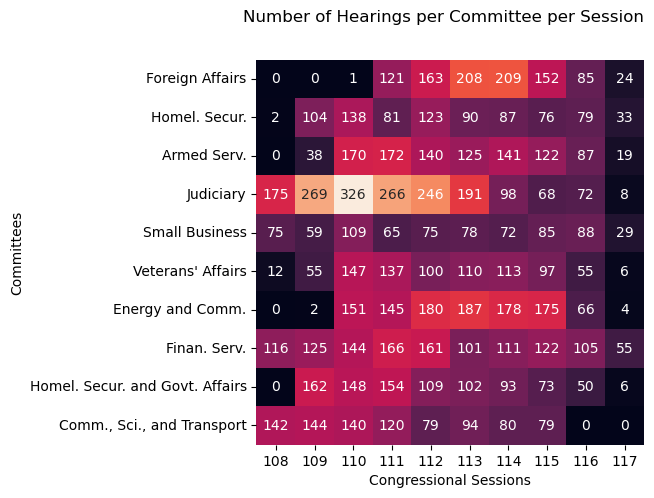

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

#specify size of heatmap
fig, ax = plt.subplots(figsize=(5, 5))
print('Hearing')
ax = sns.heatmap(pd.DataFrame.from_dict(data=Hearings, orient= 'index'), annot = True, fmt='d', cbar=False)
ax.set(xlabel="Congressional Sessions", ylabel="Committees")
fig.suptitle('Number of Hearings per Committee per Session')
plt.show()



print('\\hline')
for committee in Hearings:
    values = committee
    for i in range(108,118):
        values+='&'+str(Hearings[committee][str(i)])
    print(values+'\\\\')
    print('\hline')

Average Total Words


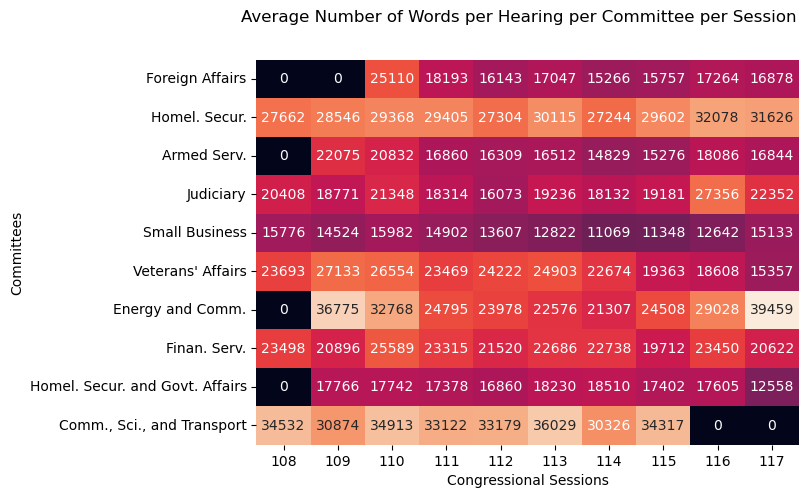

In [27]:
fig, ax = plt.subplots(figsize=(7, 5))
print('Average Total Words')
ax = sns.heatmap(pd.DataFrame.from_dict(data=Words, orient= 'index'), annot = True, fmt='.0f', cbar=False)
ax.set(xlabel="Congressional Sessions", ylabel="Committees")
fig.suptitle('Average Number of Words per Hearing per Committee per Session')
plt.show()

print('\\hline')
for committee in Words:
    values = committee
    for i in range(108,118):
        values+='&'+str(Words[committee][str(i)])
    print(values+'\\\\')
    print('\hline')

print('\\hline')
for committee in Words:
    values = committee
    for i in range(108,118):
        values+='&'+str(Words[committee][str(i)])
    print(values+'\\\\')
    print('\hline')

Witnesses


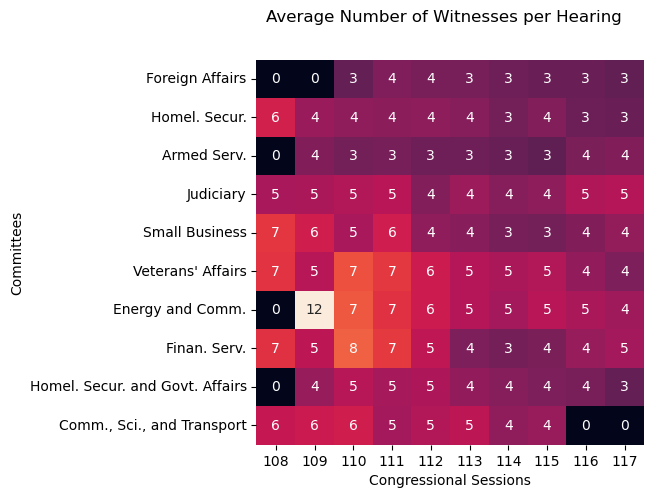

In [17]:
fig, ax = plt.subplots(figsize=(5, 5))
print('Witnesses')
ax = sns.heatmap(pd.DataFrame.from_dict(data=Witnesses, orient= 'index'), annot = True, fmt='.0f',cbar=False)
ax.set(xlabel="Congressional Sessions", ylabel="Committees")
fig.suptitle('Average Number of Witnesses per Hearing')
plt.show()

print('\\hline')
for committee in Witnesses:
    values = committee
    for i in range(108,118):
        values+='&'+str(int(Witnesses[committee][str(i)]))
    print(values+'\\\\')
    print('\hline')

Members


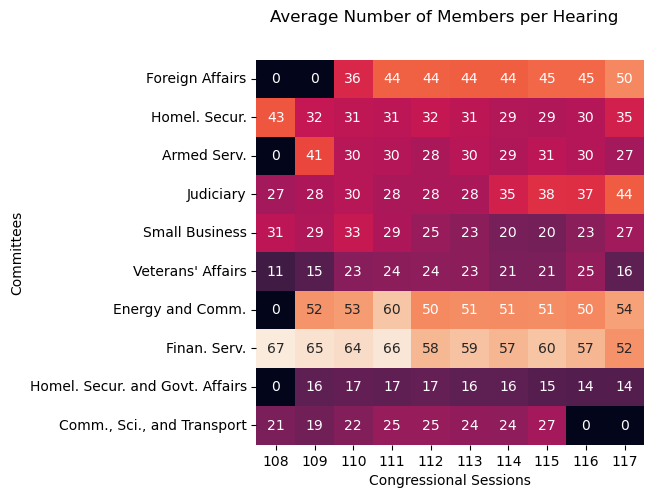

In [20]:
fig, ax = plt.subplots(figsize=(5, 5))
print('Members')
ax = sns.heatmap(pd.DataFrame.from_dict(data=Members, orient= 'index'), annot = True, fmt='.0f',cbar=False)
ax.set(xlabel="Congressional Sessions", ylabel="Committees")
fig.suptitle('Average Number of Members per Hearing')
plt.show()

print('\\hline')
for committee in Members:
    values = committee
    for i in range(108,118):
        values+='&'+str(int(Members[committee][str(i)]))
    print(values+'\\\\')
    print('\hline')

Average Utterances


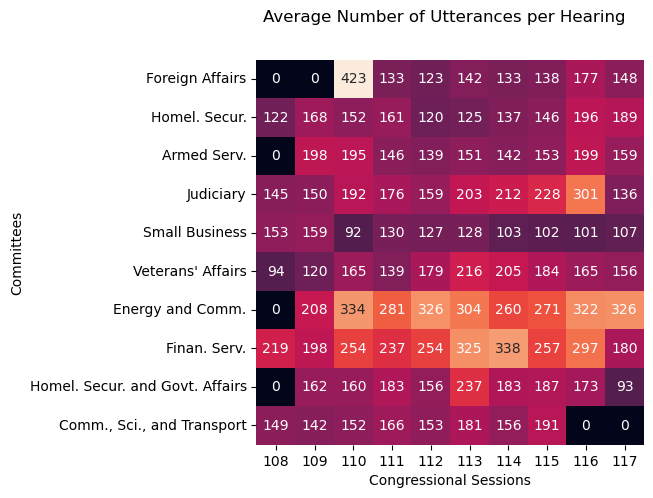

In [21]:
fig, ax = plt.subplots(figsize=(5,5))
print('Average Utterances')
ax = sns.heatmap(pd.DataFrame.from_dict(data=Utterances, orient= 'index'), annot = True, fmt='.0f',cbar=False)
ax.set(xlabel="Congressional Sessions", ylabel="Committees")
fig.suptitle('Average Number of Utterances per Hearing')
plt.show()

print('\\hline')
for committee in Utterances:
    values = committee
    for i in range(108,118):
        values+='&'+str(int(Utterances[committee][str(i)]))
    print(values+'\\\\')
    print('\hline')

Average Words per Utterances


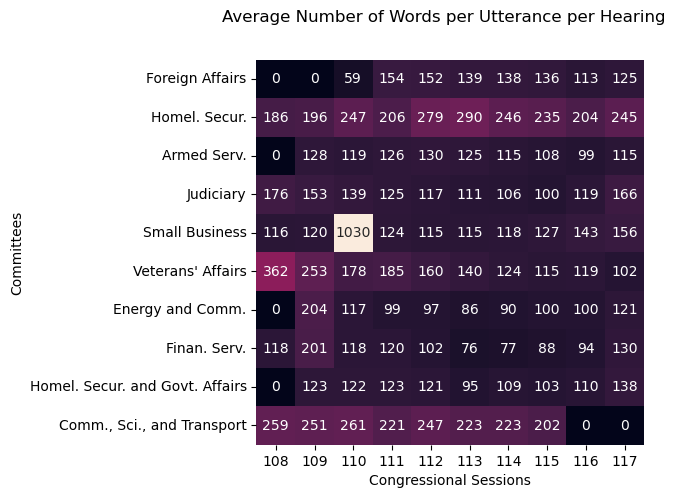

In [22]:
fig, ax = plt.subplots(figsize=(5, 5))
print('Average Words per Utterances')
sns.heatmap(pd.DataFrame.from_dict(data=UttWords, orient= 'index'), annot = True, fmt='.0f',cbar=False)
ax.set(xlabel="Congressional Sessions", ylabel="Committees")
fig.suptitle('Average Number of Words per Utterance per Hearing')
plt.show()

print('\\hline')
for committee in UttWords:
    values = committee
    for i in range(108,118):
        values+='&'+str(int(UttWords[committee][str(i)]))
    print(values+'\\\\')
    print('\hline')

In [13]:
print(sorted(Checking))

['CHRG-108hhrg87992', 'CHRG-108hhrg92119', 'CHRG-108hhrg92208', 'CHRG-108hhrg94459', 'CHRG-108shrg20730', 'CHRG-108shrg95553', 'CHRG-109hhrg20709', 'CHRG-109hhrg22549', 'CHRG-109hhrg22850', 'CHRG-109hhrg23434', 'CHRG-109hhrg26653', 'CHRG-109hhrg26754', 'CHRG-109hhrg26755', 'CHRG-109hhrg27629', 'CHRG-109hhrg28556', 'CHRG-109hhrg35626', 'CHRG-110hhrg33804', 'CHRG-110hhrg33807', 'CHRG-110hhrg34827', 'CHRG-110hhrg34830', 'CHRG-110hhrg34831', 'CHRG-110hhrg34832', 'CHRG-110hhrg34833', 'CHRG-110hhrg34834', 'CHRG-110hhrg34837', 'CHRG-110hhrg35857', 'CHRG-110hhrg36102', 'CHRG-110hhrg36103', 'CHRG-110hhrg36104', 'CHRG-110hhrg36105', 'CHRG-110hhrg36106', 'CHRG-110hhrg36107', 'CHRG-110hhrg36108', 'CHRG-110hhrg36110', 'CHRG-110hhrg36112', 'CHRG-110hhrg36113', 'CHRG-110hhrg36131', 'CHRG-110hhrg38202', 'CHRG-110hhrg38203', 'CHRG-110hhrg38205', 'CHRG-110hhrg38207', 'CHRG-110hhrg38208', 'CHRG-110hhrg38209', 'CHRG-110hhrg38639', 'CHRG-110hhrg39375', 'CHRG-110hhrg39376', 'CHRG-110hhrg39378', 'CHRG-110hhr

In [14]:
print('Aggregates: \nMembers:\t'+str(len(unique_members))+'\nWitnesses:\t'+str(len(unique_witnesses))+'\nCommittes:\t'+str(len(unique_committes))+'\nHearings:\t'+str(total_hearings))

Aggregates: 
Members:	1774
Witnesses:	69149
Committes:	76
Hearings:	16130


In [15]:
print(unique_witnesses)

{'Margie McHugh, Co-Director, National Center on Immigration Integration Policy, Migration Policy Institute', 'DiPetto, Chris, Deputy Director, Systems and Software Engineering (Developmental Test & Evaluation), Office of the Under Secretary of Defense (Acquisition and Technology)', 'Garry A. Neil, Global Head of Research and Development, Medgenics, Inc', 'Mr. David Schenker, Aufzien fellow and director, Program on Arab Politics, Washington Institute for Near East Policy', 'Dynarski, Susan, Professor of Public Policy, Education and Economics, University of Michigan, Ann Arbor, Michigan', 'National Child Abuse Coalition, Thomas L. Birch', 'Overbey, Randy, President, Alcoa Power Generating, Inc', 'Wozniak, Tina Skeldon, President, Lucas County Commissioners', 'Lewis, Rita, beneficiary, Central States Pension Plan, West Chester, OH', 'N. Jerold Cohen, Partner, Sutherland Asbill and Brennan, LLP, Atlanta, Georgia, accompanied by J.D. Fleming', 'Kosiak, Steven M.; Vice President for Budget 